# 🚗 Projeto de Análise de Carros Elétricos


### 📌 Introdução

    Com o crescimento da indústria de veículos elétricos, vejo como algo interessante analisar os dados de modelos, autonomia e tendências de mercado. Na busca de trazer conclusões sobre o assunto, trago análises estatísticas sobre o uso de carros elétricos no estado de Washignton (EUA) entre os anos 2000-2025.

<p align="center">
  <img src="https://f.i.uol.com.br/fotografia/2023/05/26/168512996364710aebd8ee8_1685129963_3x2_md.jpg" width="700">
</p>

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


tabela = pd.read_csv('Electric_Vehicle_Population_Data.csv')
df = pd.DataFrame(tabela)

Tratamento dos dados

In [33]:
df = df.drop(columns = {'Postal Code','Legislative District','DOL Vehicle ID','Vehicle Location','2020 Census Tract'})

In [34]:
def renomear_colunas (nome_anterior, nome_atual):
    return df.rename(columns= {nome_anterior: nome_atual})

In [35]:
df.columns = df.columns.str.lower()

In [36]:
colunas_traduzidas = { 'vin (1-10)' : 'placa',
                       'county': 'condado',
                       'city': 'cidade',
                       'state':'estado',
                       'model year':'ano_modelo',
                       'make':'montadora',
                       'model':'modelo',
                       'electric vehicle type':'tipo_veiculo_eletrico',
                       'clean alternative fuel vehicle (cafv) eligibility':'elegibilidade_combustivel_alternativo_limpo',
                       'electric utility':'concessionaria_eletrica',
                       'electric range':'alcance_elétrico'}
df_renomeado = df.rename(columns=colunas_traduzidas)

In [37]:
df_renomeado.columns = (
    df_renomeado.columns
    .str.strip()                             # Remove espaços nas bordas
    .str.lower()                             # Converte para minúsculas
    .str.replace(' ', '_')                   # Substitui espaços por underscores
    .str.replace('-', '_')                   # Substitui hífens por underscores
    .str.replace(r'[^\w_]', '', regex=True)  # Remove parênteses, barras e outros símbolos
)

Início da análise exploratória

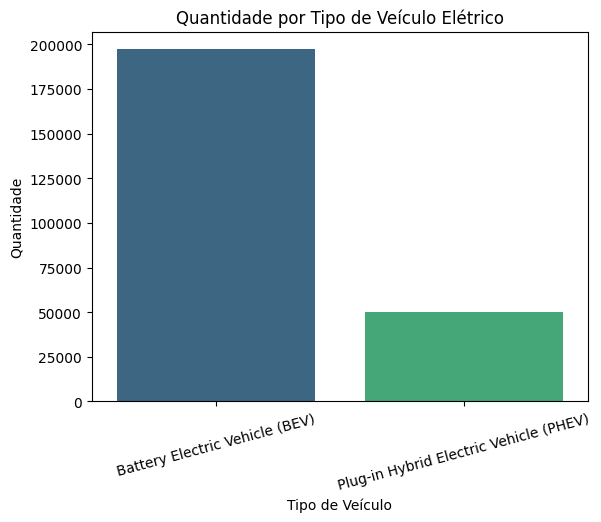

In [38]:
plt.figure()
sns.countplot(
    data=df_renomeado, 
    x='tipo_veiculo_eletrico', 
    palette="viridis",
    order=df_renomeado["tipo_veiculo_eletrico"].value_counts().index
)
plt.title("Quantidade por Tipo de Veículo Elétrico")
plt.xlabel("Tipo de Veículo")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.show()

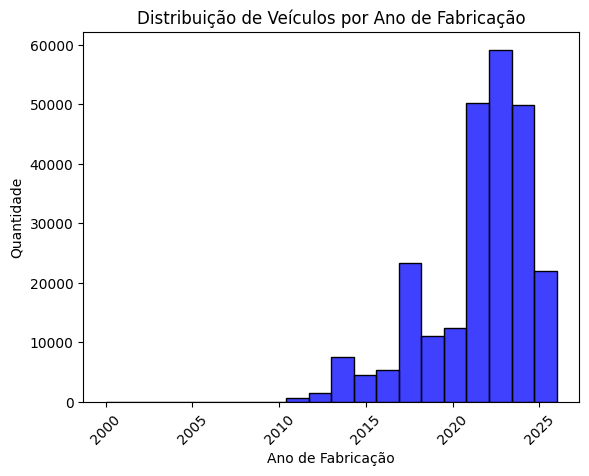

In [39]:
plt.figure()
sns.histplot(df_renomeado['ano_modelo'], bins = 20, kde= False, color = 'blue')
plt.title("Distribuição de Veículos por Ano de Fabricação",fontsize = 12)
plt.xlabel("Ano de Fabricação", fontsize = 10)
plt.ylabel("Quantidade", fontsize = 10)
plt.xticks(rotation=45)
plt.show()

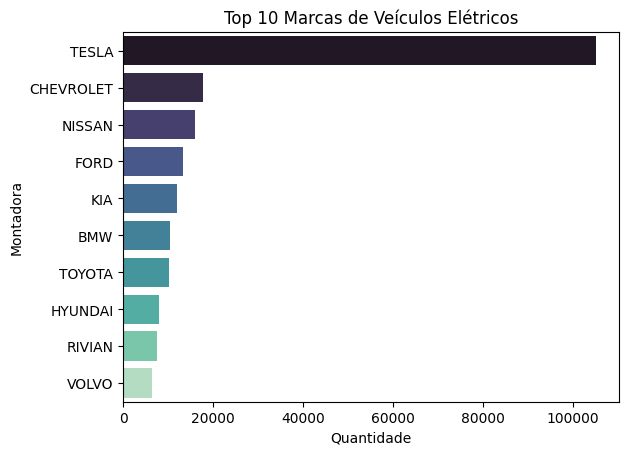

In [40]:
top_montadoras = df_renomeado["montadora"].value_counts().head(10)
plt.figure()
sns.barplot(x=top_montadoras.values, y=top_montadoras.index, palette="mako")
plt.title("Top 10 Marcas de Veículos Elétricos")
plt.xlabel("Quantidade")
plt.ylabel("Montadora")
plt.show()

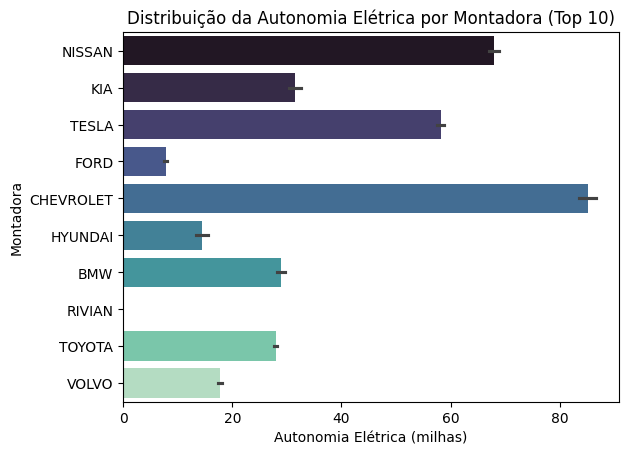

In [41]:
top_montadoras_lista = df_renomeado["montadora"].value_counts().head(10).index
df_top = df_renomeado[df_renomeado["montadora"].isin(top_montadoras_lista)]

plt.figure()
sns.barplot(x="alcance_elétrico", y="montadora", data=df_top, palette="mako")
plt.title("Distribuição da Autonomia Elétrica por Montadora (Top 10)")
plt.xlabel("Autonomia Elétrica (milhas)")
plt.ylabel("Montadora")
plt.show()

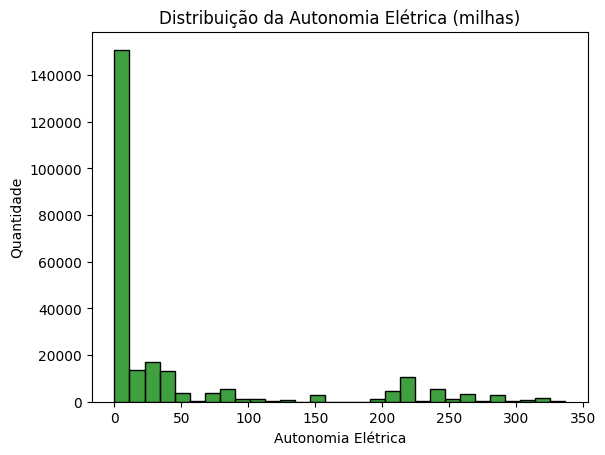

In [42]:
plt.figure()
sns.histplot(df_renomeado["alcance_elétrico"], bins=30, kde=False, color="green")
plt.title("Distribuição da Autonomia Elétrica (milhas)")
plt.xlabel("Autonomia Elétrica")
plt.ylabel("Quantidade")
plt.show()

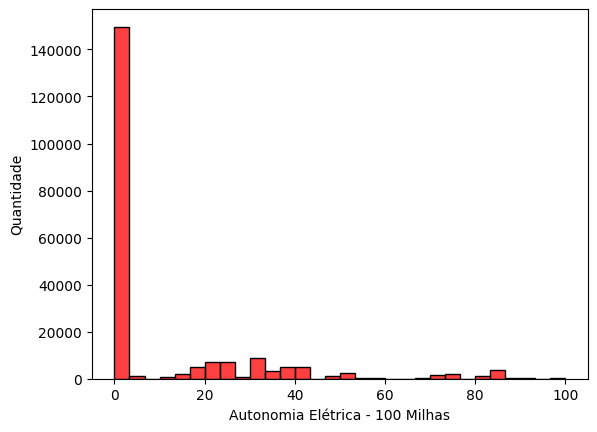

In [43]:
plt.figure()
sns.histplot(df_renomeado[df_renomeado['alcance_elétrico']<=100]['alcance_elétrico'],
             bins = 30, kde= False, color = "Red")
plt.xlabel("Autonomia Elétrica - 100 Milhas")
plt.ylabel("Quantidade")
plt.show()

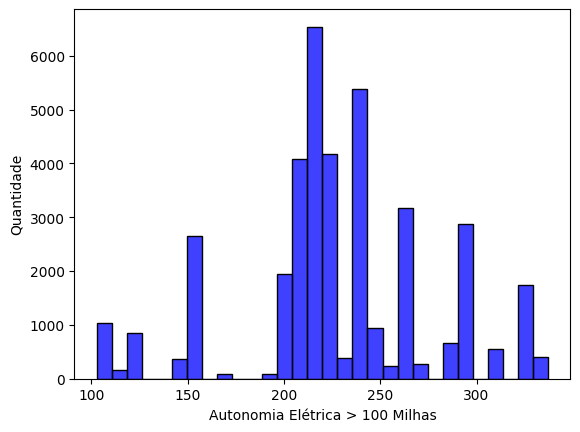

In [44]:
plt.figure()
sns.histplot(df_renomeado[df_renomeado['alcance_elétrico']>100]['alcance_elétrico'],
             bins = 30, kde= False, color = "Blue")
plt.xlabel("Autonomia Elétrica > 100 Milhas")
plt.ylabel("Quantidade")
plt.show()

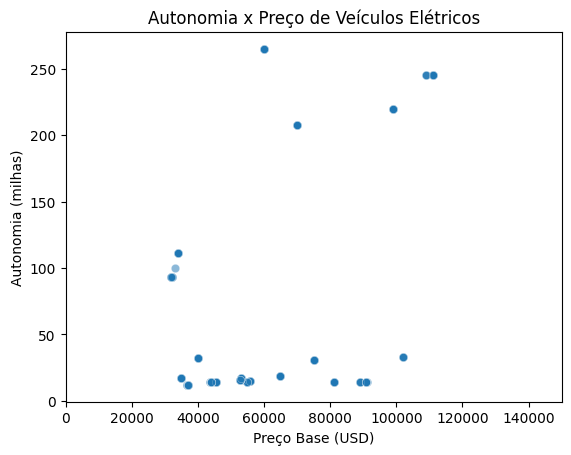

In [45]:
plt.figure()
df_filtrado = df_renomeado[df_renomeado['base_msrp'] > 0] #grande numero de linhas com valor zerado
sns.scatterplot(data=df_filtrado, x="base_msrp", y='alcance_elétrico', alpha=0.3)
plt.title("Autonomia x Preço de Veículos Elétricos")
plt.xlabel("Preço Base (USD)")
plt.ylabel("Autonomia (milhas)")
plt.xlim(0, 150000)  # Limita para evitar outliers distorcendo a escala
plt.show()

In [46]:
df_renomeado

,placa,condado,cidade,estado,ano_modelo,montadora,modelo,tipo_veiculo_eletrico,elegibilidade_combustivel_alternativo_limpo,alcance_elétrico,base_msrp,concessionaria_eletrica
0,1N4BZ0CP5G,King,Seattle,WA,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
1,KNDJX3AEXG,King,Renton,WA,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
2,5YJ3E1EB2J,King,Seattle,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
3,1C4RJXN64R,Kitsap,Bremerton,WA,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,PUGET SOUND ENERGY INC
4,5YJ3E1EB1J,Thurston,Olympia,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,PUGET SOUND ENERGY INC
...,...,...,...,...,...,...,...,...,...,...,...,...
247339,7G2CEHED0R,King,Newcastle,WA,2024,TESLA,CYBERTRUCK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
247340,1C4RJYC65R,Pierce,Puyallup,WA,2024,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
247341,7SAYGDEE0P,King,Bothell,WA,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
247342,KNDPYDAH9P,Kitsap,Bainbridge Island,WA,2023,KIA,SPORTAGE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,34.0,0.0,PUGET SOUND ENERGY INC
